In [3]:
import os
import random
import json
import shutil
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
from tqdm import tqdm
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import cv2
import lime
from lime import lime_image
import shap
from captum.attr import IntegratedGradients
from skimage.segmentation import mark_boundaries

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Loading the Dataset

In [5]:
import zipfile
import os
from tqdm import tqdm
import shutil
local_base = "/content/Dataset/combined_images"
local_status = {}
for class_name in ['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']:
    class_path = os.path.join(local_base, class_name)
    if os.path.exists(class_path):
        existing = set(os.listdir(class_path))
        local_status[class_name] = existing
    else:
        os.makedirs(class_path, exist_ok=True)
        local_status[class_name] = set()

with zipfile.ZipFile("/content/drive/MyDrive/XAI (mine)/Copy of archive (16).zip", 'r') as zf:
    all_members = zf.namelist()

    image_members = [m for m in all_members if m.endswith('.jpg')]
    print(f"Total images in zip: {len(image_members)}")
    to_extract = []
    for member in image_members:
        parts = member.split('/')
        if len(parts) >= 2 and parts[-2] in local_status:
            class_name = parts[-2]
            filename = parts[-1]
            if filename not in local_status[class_name]:
                to_extract.append(member)
    if len(to_extract) > 0:
        for member in tqdm(to_extract, desc="Extracting files"):
            zf.extract(member, "/content/Dataset")

print("\nFiles Loaded:")
total_local = 0
for class_name in ['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']:
    class_path = os.path.join(local_base, class_name)
    count = len([f for f in os.listdir(class_path) if f.endswith('.jpg')])
    total_local += count
    print(f"   {class_name}: {count} files")

print(f"\nTotal files: {total_local}/44000")


Total images in zip: 44000

Files Loaded:
   MildDemented: 10000 files
   ModerateDemented: 10000 files
   NonDemented: 12800 files
   VeryMildDemented: 11200 files

Total files: 44000/44000


# Preprocessing and Splitting

In [6]:
INPUT_DIR = "/content/Dataset/combined_images"
OUTPUT_DIR = "/content/preprocessed"
CKPT_PATH = "/content/drive/MyDrive/XAI (mine)/best_densenet.pt"
META_PATH = "/content/drive/MyDrive/XAI (mine)/meta.json"
CSV_PATH = "/content/drive/MyDrive/XAI (mine)/split.csv"

IMAGE_SIZE = 224
TRAIN_RATIO = 0.80
BATCH_SIZE = 32
NUM_EPOCHS = 40
LR = 0.01
MOMENTUM = 0.9
WEIGHT_DECAY = 1e-4
PATIENCE = 10
USE_RATIO = 1.0
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

CLASS_NAMES = sorted(os.listdir(INPUT_DIR))
NUM_CLASSES = len(CLASS_NAMES)
print(f'Classes ({NUM_CLASSES}): {CLASS_NAMES}')

Classes (4): ['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']


In [7]:
all_paths = []
all_labels = []

for idx, cls in enumerate(CLASS_NAMES):
    cls_dir = os.path.join(INPUT_DIR, cls)
    files = [f for f in os.listdir(cls_dir) if os.path.isfile(os.path.join(cls_dir, f))]
    random.shuffle(files)
    n = int(len(files) * USE_RATIO)
    for fname in files[:n]:
        all_paths.append(os.path.join(cls_dir, fname))
        all_labels.append(idx)

print(f"Total images: {len(all_paths)}")
for idx, cls in enumerate(CLASS_NAMES):
    print(f"  {cls}: {all_labels.count(idx)}")

Total images: 44000
  MildDemented: 10000
  ModerateDemented: 10000
  NonDemented: 12800
  VeryMildDemented: 11200


In [8]:
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    all_paths, all_labels,
    test_size=1 - TRAIN_RATIO,
    stratify=all_labels,
    random_state=SEED,
)

val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels,
    test_size=0.5,
    stratify=temp_labels,
    random_state=SEED,
)

print(f"Train: {len(train_paths)} | Val: {len(val_paths)} | Test: {len(test_paths)}")

train_set = set(train_paths)
val_set = set(val_paths)
test_set = set(test_paths)

overlap_train_val = len(train_set & val_set)
overlap_train_test = len(train_set & test_set)
overlap_val_test = len(val_set & test_set)

print(f"Train-Val overlap: {overlap_train_val}")
print(f"Train-Test overlap: {overlap_train_test}")
print(f"Val-Test overlap: {overlap_val_test}")

if overlap_train_val == 0 and overlap_train_test == 0 and overlap_val_test == 0:
    print("No data leakage")
else:
    print("Data leakage detected!")

for name, lbls in [("train", train_labels), ("val", val_labels), ("test", test_labels)]:
    c = Counter(lbls)
    print(f"  {name}: {dict(sorted(c.items()))}")

Train: 35200 | Val: 4400 | Test: 4400
Train-Val overlap: 0
Train-Test overlap: 0
Val-Test overlap: 0
No data leakage
  train: {0: 8000, 1: 8000, 2: 10240, 3: 8960}
  val: {0: 1000, 1: 1000, 2: 1280, 3: 1120}
  test: {0: 1000, 1: 1000, 2: 1280, 3: 1120}


In [9]:
if os.path.exists(OUTPUT_DIR):
    shutil.rmtree(OUTPUT_DIR)
os.makedirs(OUTPUT_DIR, exist_ok=True)

def save_tensors(paths, labels, split_name):
    split_dir = os.path.join(OUTPUT_DIR, split_name)
    filename_usage = {}

    for path, label in tqdm(zip(paths, labels), total=len(paths), desc=f"Saving {split_name}"):
        cls_name = CLASS_NAMES[label]
        out_dir = os.path.join(split_dir, cls_name)
        os.makedirs(out_dir, exist_ok=True)

        base_fname = os.path.splitext(os.path.basename(path))[0]
        tracking_key = f"{cls_name}_{base_fname}"

        if tracking_key in filename_usage:
            filename_usage[tracking_key] += 1
            unique_fname = f"{base_fname}_dup{filename_usage[tracking_key]}.pt"
        else:
            filename_usage[tracking_key] = 0
            unique_fname = f"{base_fname}.pt"

        out_path = os.path.join(out_dir, unique_fname)

        img = Image.open(path).convert("L")
        img = img.resize((IMAGE_SIZE, IMAGE_SIZE))
        tensor = transforms.ToTensor()(img)
        tensor = (tensor * 255).byte()
        tensor = tensor.repeat(3, 1, 1)
        torch.save(tensor, out_path)

save_tensors(train_paths, train_labels, "train")
save_tensors(val_paths, val_labels, "val")
save_tensors(test_paths, test_labels, "test")

print("All tensors saved.")

Saving test: 100%|██████████| 4400/4400 [00:11<00:00, 369.38it/s]

All tensors saved.


# Loading Dataset

In [10]:
normalize = transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)

train_augment = transforms.Compose([
    transforms.RandomRotation(degrees=10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
])

class AlzheimerDataset(Dataset):
    def __init__(self, split_dir, class_names, augment=False):
        self.samples = []
        self.augment = augment
        for idx, cls in enumerate(class_names):
            cls_dir = os.path.join(split_dir, cls)
            if not os.path.isdir(cls_dir): continue
            for fname in os.listdir(cls_dir):
                if fname.endswith(".pt"):
                    self.samples.append((os.path.join(cls_dir, fname), idx))

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        tensor = torch.load(path, weights_only=True).float() / 255.0
        if self.augment:
            tensor = train_augment(tensor)
        return normalize(tensor), label

    def get_labels(self): return [s[1] for s in self.samples]

train_ds = AlzheimerDataset(os.path.join(OUTPUT_DIR, "train"), CLASS_NAMES, augment=True)
val_ds   = AlzheimerDataset(os.path.join(OUTPUT_DIR, "val"),   CLASS_NAMES)
test_ds  = AlzheimerDataset(os.path.join(OUTPUT_DIR, "test"),  CLASS_NAMES)
print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")

Train: 35200 | Val: 4400 | Test: 4400


In [11]:
train_labels_list = train_ds.get_labels()
class_counts = Counter(train_labels_list)
sample_weights = [1.0 / class_counts[l] for l in train_labels_list]
sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler, num_workers=4, pin_memory=True, persistent_workers=True)
val_loader = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True, persistent_workers=True)
test_loader = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True, persistent_workers=True)
print("Class weights:", {CLASS_NAMES[k]: round(1.0 / v, 5) for k, v in sorted(class_counts.items())})

Class weights: {'MildDemented': 0.00013, 'ModerateDemented': 0.00013, 'NonDemented': 0.0001, 'VeryMildDemented': 0.00011}


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


# DenseNet-121 Model

In [12]:
def build_densenet(num_classes):
    model = models.densenet121(weights=None)
    in_features = model.classifier.in_features
    model.classifier = nn.Linear(in_features, num_classes)
    return model

model = build_densenet(NUM_CLASSES).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=1e-4)
scaler = torch.amp.GradScaler()

# Training

In [ ]:
def run_epoch(loader, model, criterion, optimizer=None, scaler=None, desc=""):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss, correct, total = 0.0, 0, 0

    with (torch.enable_grad() if is_train else torch.no_grad()):
        for images, labels in tqdm(loader, desc=desc, leave=False):
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            with torch.amp.autocast(device_type='cuda'):
                outputs = model(images)
                loss    = criterion(outputs, labels)
            if is_train:
                optimizer.zero_grad()
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            correct    += (outputs.argmax(1) == labels).sum().item()
            total_loss += loss.item() * labels.size(0)
            total      += labels.size(0)

    return total_loss / total, correct / total


history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc, patience_ctr = 0.0, 0

for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(train_loader, model, criterion, optimizer, scaler,
                                desc=f"Epoch {epoch}/{NUM_EPOCHS} [train]")
    vl_loss, vl_acc = run_epoch(val_loader, model, criterion,
                                desc=f"Epoch {epoch}/{NUM_EPOCHS} [val]")

    history['train_loss'].append(tr_loss);  history['train_acc'].append(tr_acc)
    history['val_loss'].append(vl_loss);    history['val_acc'].append(vl_acc)

    print(f"Epoch {epoch:02d} | train loss={tr_loss:.4f} acc={tr_acc*100:.2f}% | "
          f"val loss={vl_loss:.4f} acc={vl_acc*100:.2f}%")

    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        torch.save(model.state_dict(), CKPT_PATH)
        patience_ctr = 0
        print(f"  Best val_acc={best_val_acc*100:.2f}% — saved.")
    else:
        patience_ctr += 1
        if patience_ctr >= PATIENCE:
            print(f"  Early stopping at epoch {epoch}.")
            break

print(f"\nBest val accuracy: {best_val_acc*100:.2f}%")

Epoch 1/40 [train]:   0%|          | 0/1100 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Epoch 01 | train loss=0.8469 acc=61.72% | val loss=1.2531 acc=62.23%
  Best val_acc=62.23% — saved.


Epoch 02 | train loss=0.4468 acc=81.08% | val loss=0.3047 acc=87.48%
  Best val_acc=87.48% — saved.


Epoch 03 | train loss=0.2545 acc=89.89% | val loss=0.4283 acc=84.50%


Epoch 04 | train loss=0.1499 acc=94.24% | val loss=0.5169 acc=83.86%


...

Epoch 21 | train loss=0.0135 acc=99.56% | val loss=0.0045 acc=99.86%
  Best val_acc=99.86% — saved.


Epoch 22 | train loss=0.0083 acc=99.75% | val loss=0.0151 acc=99.43%


Epoch 23 | train loss=0.0036 acc=99.90% | val loss=0.0036 acc=99.89%
  Best val_acc=99.89% — saved.


Epoch 24 | train loss=0.0060 acc=99.80% | val loss=0.0068 acc=99.82%


KeyboardInterrupt: 

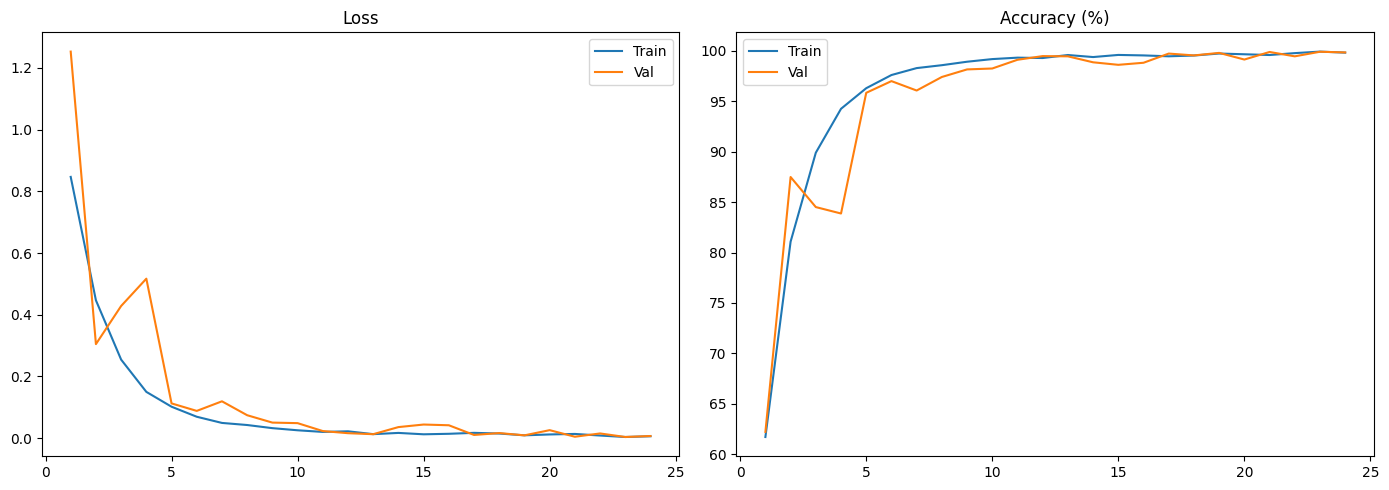

In [ ]:
epochs_range = range(1, len(history['train_loss']) + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(epochs_range, history['train_loss'], label='Train')
axes[0].plot(epochs_range, history['val_loss'],   label='Val')
axes[0].set_title('Loss')
axes[0].legend()
axes[1].plot(epochs_range, [a*100 for a in history['train_acc']], label='Train')
axes[1].plot(epochs_range, [a*100 for a in history['val_acc']],   label='Val')
axes[1].set_title('Accuracy (%)'); axes[1].legend()
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/XAI (mine)/densenet_curves.png', dpi=150)
plt.show()

Testing: 100%|██████████| 138/138 [00:13<00:00, 10.18it/s]


Test Accuracy: 99.93%

                  precision    recall  f1-score   support

    MildDemented       1.00      1.00      1.00      1000
ModerateDemented       1.00      1.00      1.00      1000
     NonDemented       1.00      1.00      1.00      1280
VeryMildDemented       1.00      1.00      1.00      1120

        accuracy                           1.00      4400
       macro avg       1.00      1.00      1.00      4400
    weighted avg       1.00      1.00      1.00      4400



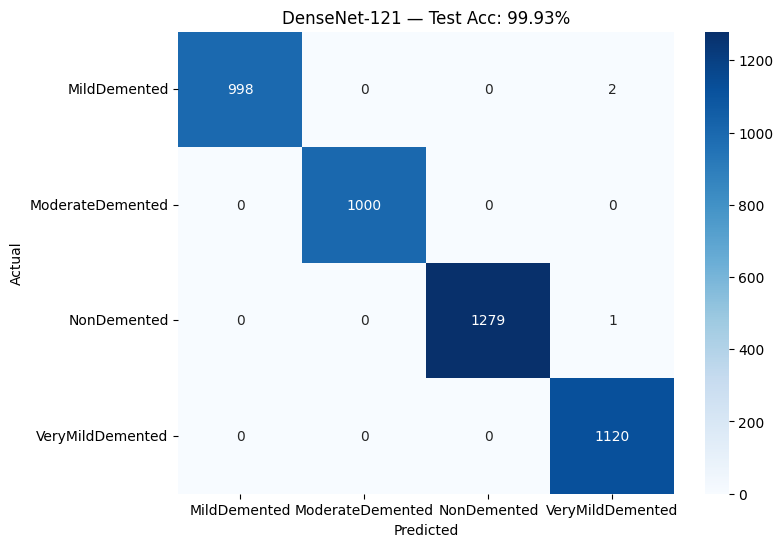

In [ ]:
model.load_state_dict(torch.load(CKPT_PATH, map_location=device))
model.eval()

all_preds, all_true = [], []
with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Testing"):
        with torch.amp.autocast(device_type='cuda'):
            preds = model(images.to(device)).argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_true.extend(labels.numpy())

test_acc = np.mean(np.array(all_preds) == np.array(all_true))
print(f"Test Accuracy: {test_acc*100:.2f}%\n")
print(classification_report(all_true, all_preds, target_names=CLASS_NAMES))

cm = confusion_matrix(all_true, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.title(f'DenseNet-121 — Test Acc: {test_acc*100:.2f}%')
plt.savefig('/content/drive/MyDrive/XAI (mine)/densenet_cm.png', dpi=150)
plt.show()

# XAI (GradCam)

In [13]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        target_layer.register_forward_hook(self.save_activation)
        target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output.detach()

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate_cam(self, input_image, target_class=None):
        model_output = self.model(input_image)

        if target_class is None:
            target_class = model_output.argmax(dim=1).item()

        self.model.zero_grad()
        class_score = model_output[0, target_class]
        class_score.backward()

        pooled_gradients = torch.mean(self.gradients, dim=[0, 2, 3])

        for i in range(self.activations.size(1)):
            self.activations[:, i, :, :] *= pooled_gradients[i]

        heatmap = torch.mean(self.activations, dim=1).squeeze()
        heatmap = torch.maximum(heatmap, torch.zeros_like(heatmap))
        heatmap /= torch.max(heatmap)

        return heatmap.cpu().numpy(), target_class

target_layer = model.features.denseblock4.denselayer16.conv2
grad_cam = GradCAM(model, target_layer)

print("Grad-CAM initialized")

Grad-CAM initialized


In [14]:
def denormalize_image(tensor):
    tensor = tensor.clone()
    for t, m, s in zip(tensor, IMAGENET_MEAN, IMAGENET_STD):
        t.mul_(s).add_(m)
    return torch.clamp(tensor, 0, 1)

def apply_colormap(img, heatmap):
    heatmap_colored = plt.get_cmap('jet')(heatmap)[:, :, :3]
    heatmap_colored = cv2.resize(heatmap_colored, (img.shape[1], img.shape[0]))
    overlay = heatmap_colored * 0.4 + img * 0.6
    return np.clip(overlay, 0, 1)

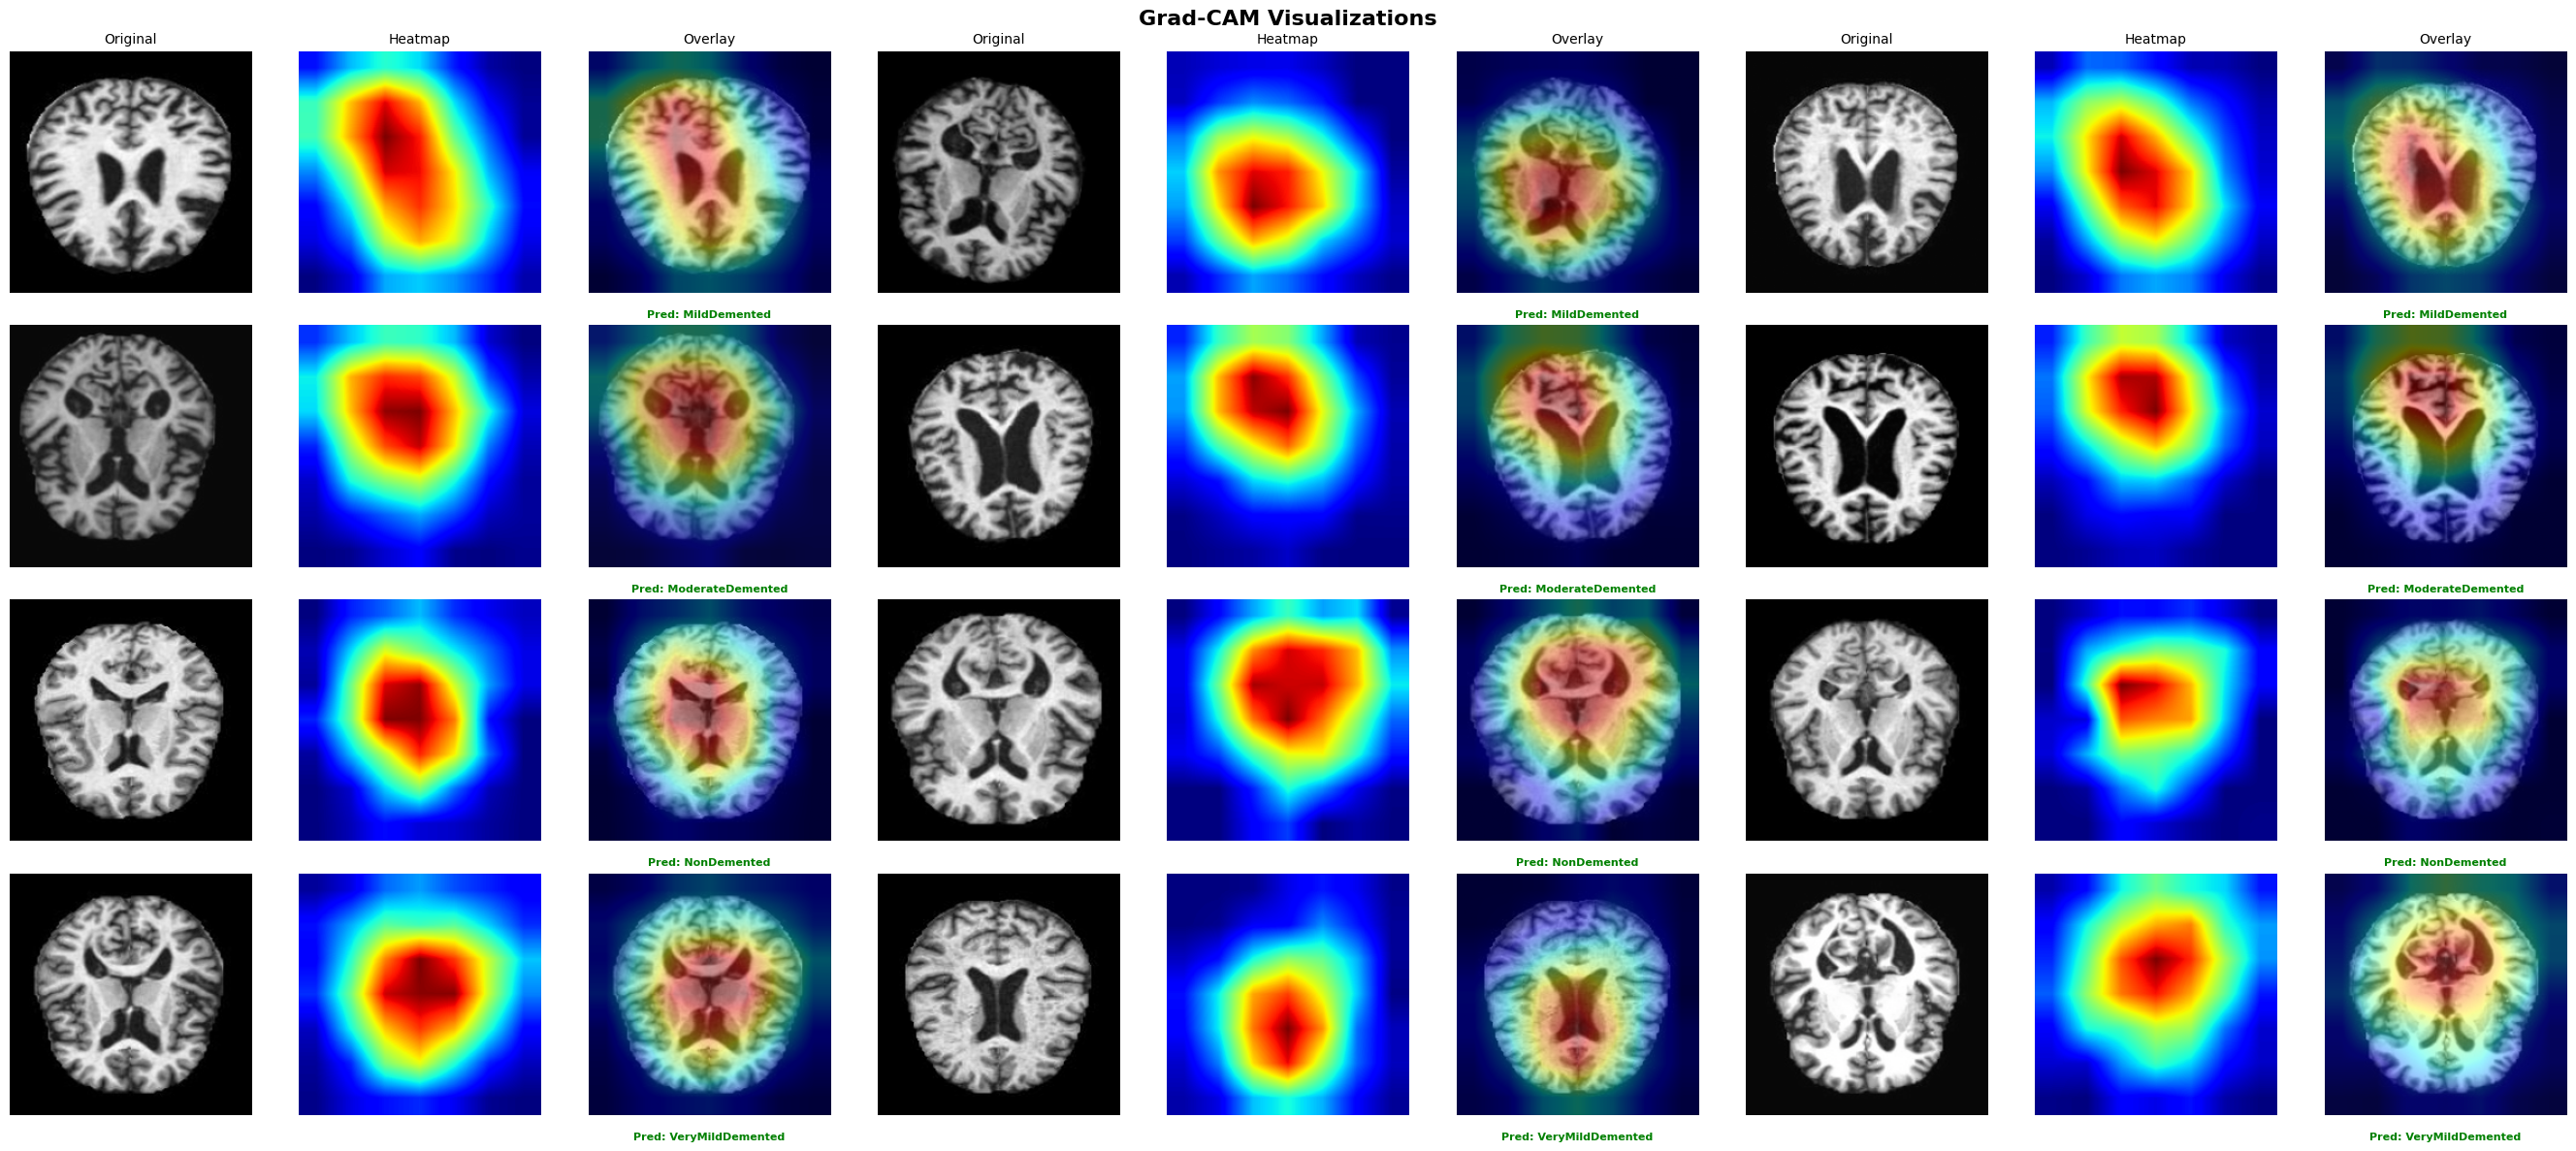

In [ ]:
model.eval()
num_samples = 3
fig, axes = plt.subplots(NUM_CLASSES, num_samples * 3, figsize=(num_samples * 9, NUM_CLASSES * 3))
fig.suptitle('Grad-CAM Visualizations', fontsize=16, fontweight='bold')

for class_idx, class_name in enumerate(CLASS_NAMES):
    class_samples = [(img, lbl) for img, lbl in test_ds if lbl == class_idx]
    selected = random.sample(range(len(class_samples)), min(num_samples, len(class_samples)))

    for sample_idx, data_idx in enumerate(selected):
        img_tensor, label = class_samples[data_idx]
        input_tensor = img_tensor.unsqueeze(0).to(device)

        with torch.set_grad_enabled(True):
            heatmap, pred_class = grad_cam.generate_cam(input_tensor)

        img_denorm = denormalize_image(img_tensor)
        img_np = img_denorm.permute(1, 2, 0).cpu().numpy()
        heatmap_resized = cv2.resize(heatmap, (IMAGE_SIZE, IMAGE_SIZE))
        overlay = apply_colormap(img_np, heatmap_resized)

        col = sample_idx * 3

        axes[class_idx, col].imshow(img_np)
        axes[class_idx, col].axis('off')
        if sample_idx == 0:
            axes[class_idx, col].set_ylabel(class_name, fontsize=10, fontweight='bold')
        if class_idx == 0:
            axes[class_idx, col].set_title('Original', fontsize=10)

        axes[class_idx, col + 1].imshow(heatmap_resized, cmap='jet')
        axes[class_idx, col + 1].axis('off')
        if class_idx == 0:
            axes[class_idx, col + 1].set_title('Heatmap', fontsize=10)

        axes[class_idx, col + 2].imshow(overlay)
        axes[class_idx, col + 2].axis('off')
        pred_label = CLASS_NAMES[pred_class]
        color = 'green' if pred_class == label else 'red'
        if class_idx == 0:
            axes[class_idx, col + 2].set_title('Overlay', fontsize=10)
        axes[class_idx, col + 2].text(0.5, -0.1, f'Pred: {pred_label}',
                                       transform=axes[class_idx, col + 2].transAxes,
                                       ha='center', fontsize=8, color=color, fontweight='bold')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/XAI (mine)/gradcam_all.png', dpi=150, bbox_inches='tight')
plt.show()


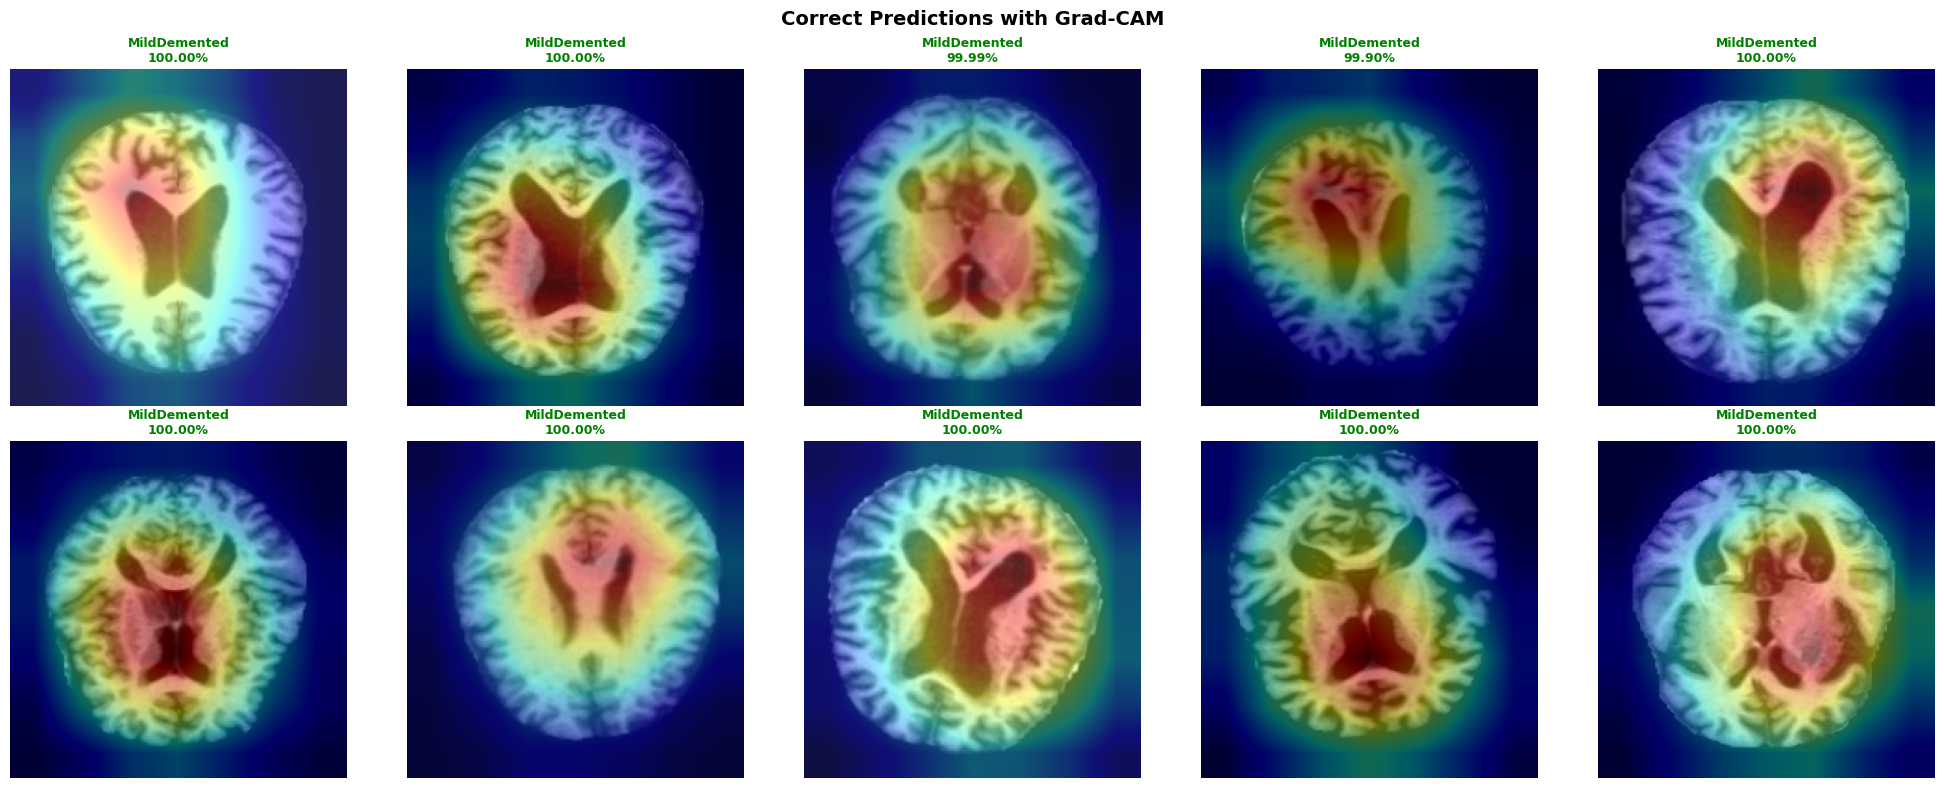

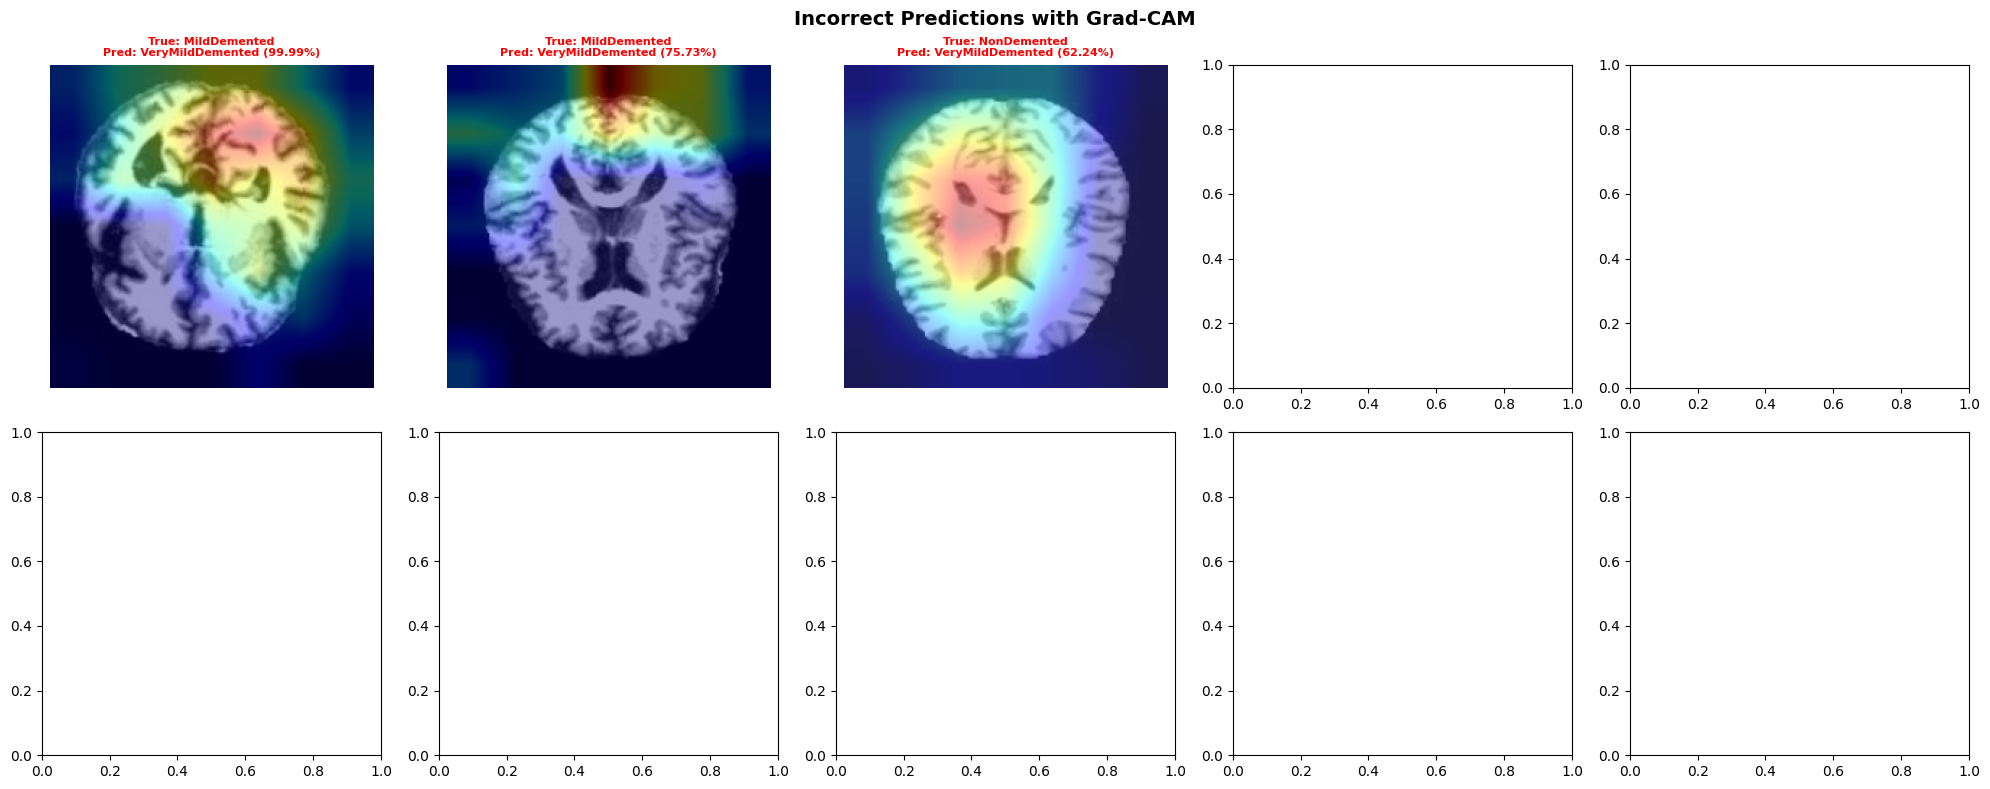

Grad-CAM visualizations complete


In [ ]:
def get_predictions_with_gradcam(loader, num_samples=10):
    model.eval()
    correct = []
    incorrect = []

    with torch.set_grad_enabled(True):
        for images, labels in loader:
            for i in range(len(images)):
                if len(correct) >= num_samples and len(incorrect) >= num_samples:
                    break

                img = images[i:i+1].to(device)
                true_label = labels[i].item()

                output = model(img)
                pred = output.argmax(dim=1).item()
                conf = torch.softmax(output, dim=1)[0, pred].item()

                heatmap, _ = grad_cam.generate_cam(img, target_class=pred)

                data = {
                    'image': images[i],
                    'true': true_label,
                    'pred': pred,
                    'conf': conf,
                    'heatmap': heatmap
                }

                if pred == true_label and len(correct) < num_samples:
                    correct.append(data)
                elif pred != true_label and len(incorrect) < num_samples:
                    incorrect.append(data)

            if len(correct) >= num_samples and len(incorrect) >= num_samples:
                break

    return correct, incorrect

correct_samples, incorrect_samples = get_predictions_with_gradcam(test_loader, num_samples=10)

# Correct predictions
if correct_samples:
    fig, axes = plt.subplots(2, 5, figsize=(20, 8))
    fig.suptitle('Correct Predictions with Grad-CAM', fontsize=14, fontweight='bold')

    for idx, sample in enumerate(correct_samples[:10]):
        row = idx // 5
        col = idx % 5

        img_denorm = denormalize_image(sample['image'])
        img_np = img_denorm.permute(1, 2, 0).cpu().numpy()
        heatmap_resized = cv2.resize(sample['heatmap'], (IMAGE_SIZE, IMAGE_SIZE))
        overlay = apply_colormap(img_np, heatmap_resized)

        axes[row, col].imshow(overlay)
        axes[row, col].axis('off')
        axes[row, col].set_title(f"{CLASS_NAMES[sample['true']]}\n{sample['conf']:.2%}",
                                 fontsize=9, color='green', fontweight='bold')

    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/XAI (mine)/gradcam_correct.png', dpi=150)
    plt.show()

# Incorrect predictions
if incorrect_samples:
    fig, axes = plt.subplots(2, 5, figsize=(20, 8))
    fig.suptitle('Incorrect Predictions with Grad-CAM', fontsize=14, fontweight='bold')

    for idx, sample in enumerate(incorrect_samples[:10]):
        row = idx // 5
        col = idx % 5

        img_denorm = denormalize_image(sample['image'])
        img_np = img_denorm.permute(1, 2, 0).cpu().numpy()
        heatmap_resized = cv2.resize(sample['heatmap'], (IMAGE_SIZE, IMAGE_SIZE))
        overlay = apply_colormap(img_np, heatmap_resized)

        axes[row, col].imshow(overlay)
        axes[row, col].axis('off')
        axes[row, col].set_title(f"True: {CLASS_NAMES[sample['true']]}\nPred: {CLASS_NAMES[sample['pred']]} ({sample['conf']:.2%})",
                                 fontsize=8, color='red', fontweight='bold')

    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/XAI (mine)/gradcam_incorrect.png', dpi=150)
    plt.show()

print("Grad-CAM visualizations complete")

### LIME

In [15]:
model.load_state_dict(torch.load(CKPT_PATH, map_location=device))
model.eval()

DenseNet(
  (features): Sequential(
    (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu

In [16]:
import gc, os
os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"

def disable_inplace_relu(m):
    for module in m.modules():
        if isinstance(module, torch.nn.ReLU):
            module.inplace = False

# one correct prediction per class from test set
def select_one_per_class(dataset, model, class_names, device):
    model.eval()
    selected = {}
    with torch.no_grad():
        for img_tensor, label in dataset:
            if label in selected:
                continue
            pred = model(img_tensor.unsqueeze(0).to(device)).argmax().item()
            if pred == label:
                selected[label] = {'tensor': img_tensor, 'true': label, 'pred': pred}
            if len(selected) == len(class_names):
                break
    # sorted by class index
    return [selected[i] for i in range(len(class_names))]

samples = select_one_per_class(test_ds, model, CLASS_NAMES, device)
print("Selected samples:")
for s in samples:
    print(f"  {CLASS_NAMES[s['true']]}")

Selected samples:
  MildDemented
  ModerateDemented
  NonDemented
  VeryMildDemented


In [17]:
class LIMEExplainer:
    def __init__(self, model, class_names):
        self.model = model
        self.class_names = class_names
        self.explainer = lime_image.LimeImageExplainer()

    def predict_fn(self, images):
        self.model.eval()
        batch = torch.from_numpy(images).permute(0, 3, 1, 2).float().to(device)
        normalize = transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
        batch = torch.stack([normalize(img) for img in batch])
        with torch.no_grad():
            probs = torch.softmax(self.model(batch), dim=1)
        return probs.cpu().numpy()

    def explain(self, image_tensor, num_samples=1000):
        img_np = denormalize_image(image_tensor).permute(1, 2, 0).cpu().numpy()
        with torch.no_grad():
            pred_class = self.model(
                image_tensor.unsqueeze(0).to(device)
            ).argmax().item()
        explanation = self.explainer.explain_instance(
            img_np, self.predict_fn,
            top_labels=len(self.class_names),
            hide_color=0,
            num_samples=num_samples
        )
        return explanation, pred_class, img_np

lime_explainer = LIMEExplainer(model, CLASS_NAMES)

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

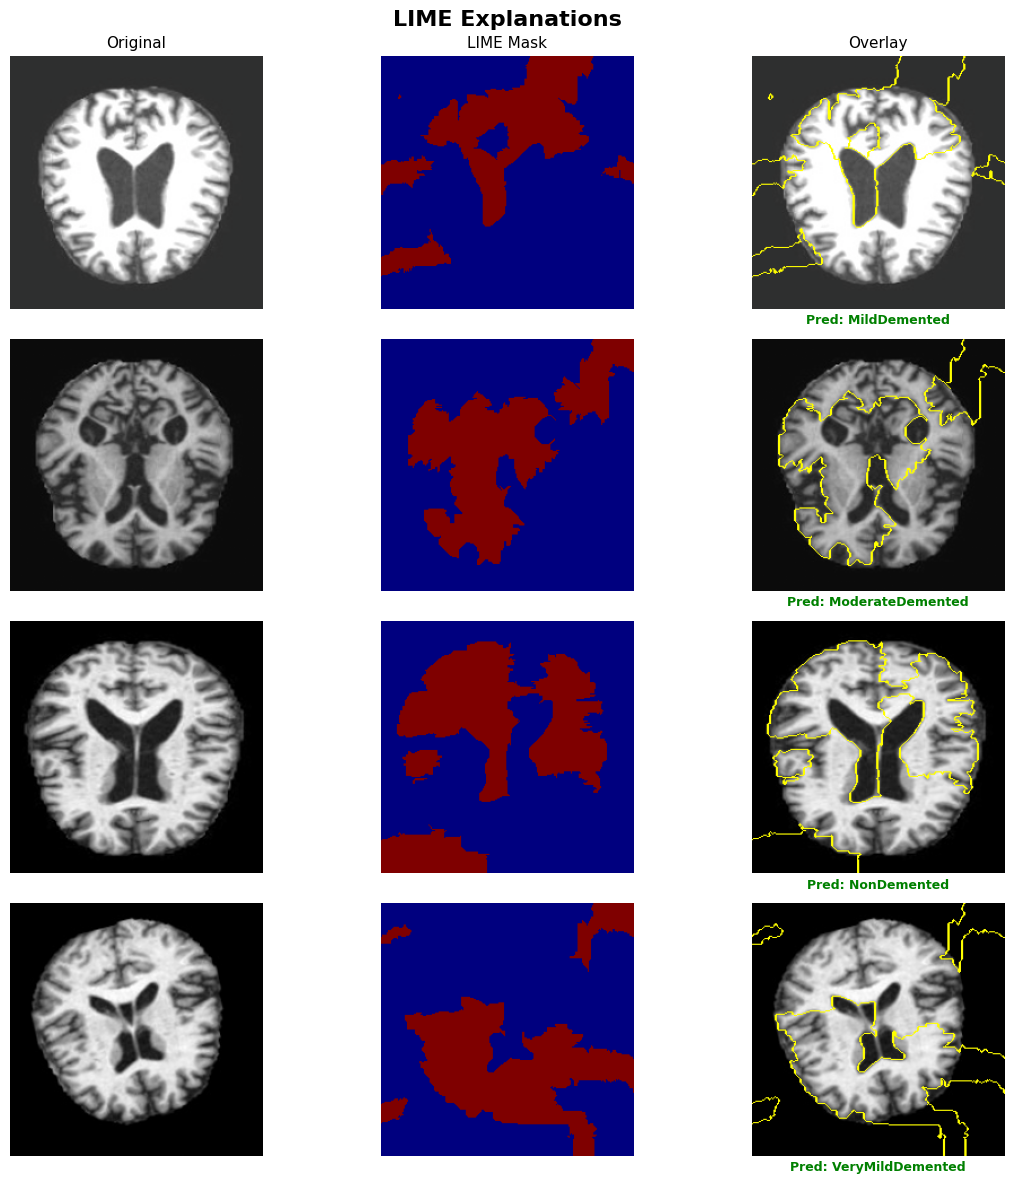

In [18]:
fig, axes = plt.subplots(NUM_CLASSES, 3, figsize=(12, NUM_CLASSES * 3))
fig.suptitle('LIME Explanations', fontsize=16, fontweight='bold')

col_titles = ['Original', 'LIME Mask', 'Overlay']
for col, title in enumerate(col_titles):
    axes[0, col].set_title(title, fontsize=11)

for row, sample in enumerate(samples):
    explanation, pred_class, img_np = lime_explainer.explain(sample['tensor'])

    temp_img, mask = explanation.get_image_and_mask(
        pred_class, positive_only=True, num_features=10, hide_rest=False
    )
    boundary_img = mark_boundaries(img_np, mask.astype(int))

    lime_attr = np.zeros(mask.shape)
    lime_attr[mask == 1] = 1.0

    color = 'green' if pred_class == sample['true'] else 'red'

    axes[row,0].imshow(img_np)
    axes[row,0].set_ylabel(CLASS_NAMES[sample['true']], fontsize=10, fontweight='bold')
    axes[row,0].axis('off')

    axes[row,1].imshow(lime_attr, cmap='jet')
    axes[row,1].axis('off')

    axes[row,2].imshow(boundary_img)
    axes[row,2].axis('off')
    axes[row,2].text(0.5, -0.06, f"Pred: {CLASS_NAMES[pred_class]}",
                     transform=axes[row, 2].transAxes, ha='center', fontsize=9,
                     color=color, fontweight='bold')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/XAI (mine)/lime_all_classes.png', dpi=150, bbox_inches='tight')
plt.show()

### SHAP

In [19]:
for name in ['shap_explainer', 'background_data', 'shap_values']:
    if name in globals(): del globals()[name]
gc.collect()
torch.cuda.empty_cache()

model_cpu = build_densenet(NUM_CLASSES)
ckpt = torch.load(CKPT_PATH, map_location='cpu')
model_cpu.load_state_dict(ckpt, strict=False)
model_cpu.eval()
disable_inplace_relu(model_cpu)

class SHAPExplainer:
    def __init__(self, model, n_background=10):
        self.model = model.eval()
        background_data = torch.stack(
            [train_ds[i][0] for i in range(n_background)]
        )
        self.explainer = shap.GradientExplainer(model, background_data)
        print(f"Background: {background_data.shape}")

    def explain(self, image_tensor):
        input_tensor = image_tensor.unsqueeze(0).requires_grad_(True)
        with torch.no_grad():
            pred_class = self.model(image_tensor.unsqueeze(0)).argmax().item()
        shap_values = self.explainer.shap_values(input_tensor)
        return shap_values, pred_class

shap_explainer = SHAPExplainer(model_cpu, n_background=10)

Background: torch.Size([10, 3, 224, 224])


Processing MildDemented (1/4)...
  Done.
Processing ModerateDemented (2/4)...
  Done.
Processing NonDemented (3/4)...
  Done.
Processing VeryMildDemented (4/4)...
  Done.


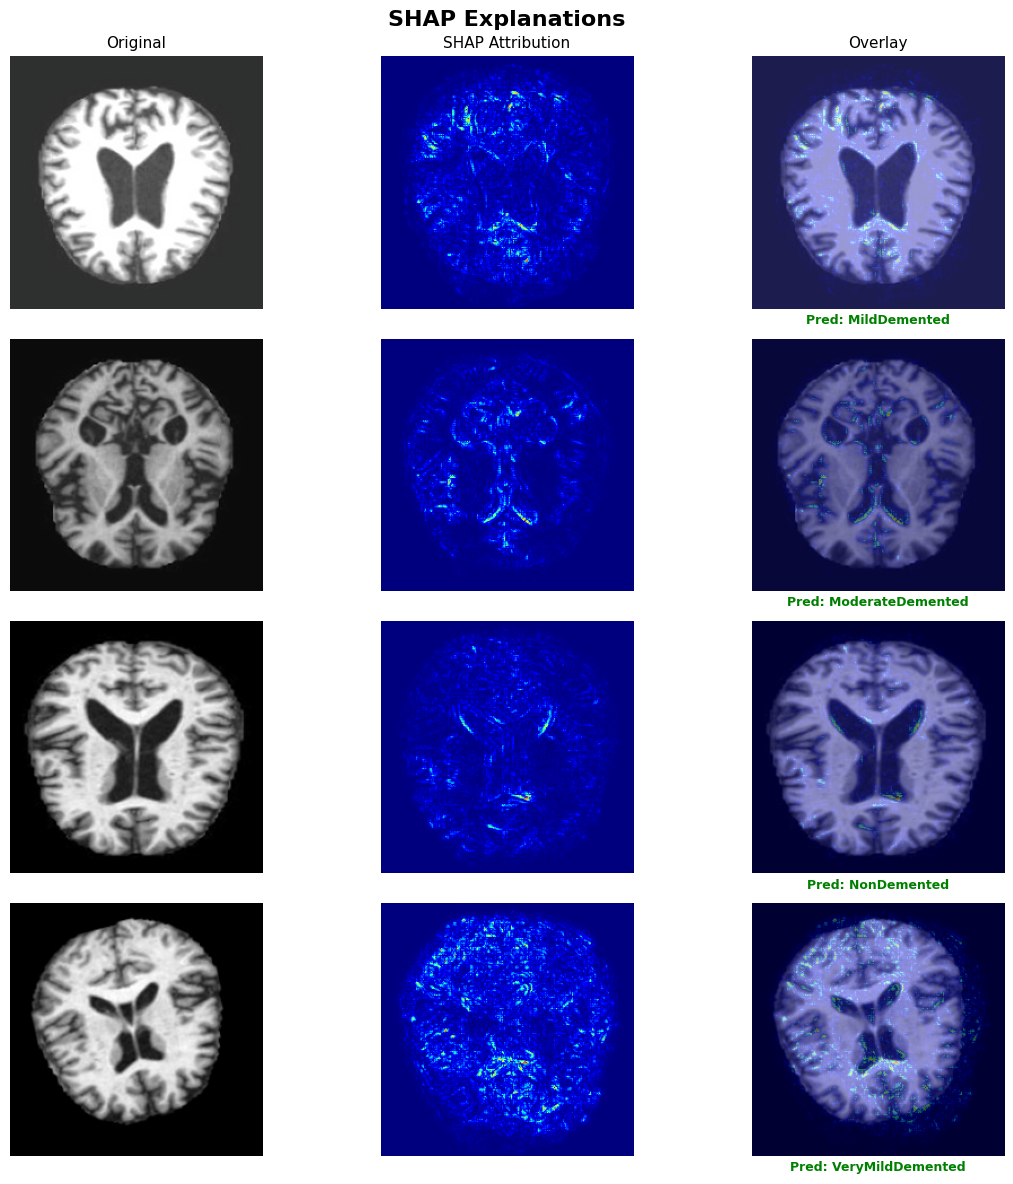

SHAP done


In [22]:
fig, axes = plt.subplots(NUM_CLASSES, 3, figsize=(12, NUM_CLASSES * 3))
fig.suptitle('SHAP Explanations', fontsize=16, fontweight='bold')

col_titles = ['Original', 'SHAP Attribution', 'Overlay']
for col, title in enumerate(col_titles):
    axes[0, col].set_title(title, fontsize=11)

for row, sample in enumerate(samples):
    print(f"Processing {CLASS_NAMES[sample['true']]} ({row+1}/{NUM_CLASSES})...")
    img_tensor = sample['tensor']
    shap_values, pred_class = shap_explainer.explain(img_tensor)

    img_np = denormalize_image(img_tensor).permute(1, 2, 0).numpy()

    shap_attr = shap_values[0]
    shap_attr = shap_attr[:, :, :, pred_class]
    shap_attr = np.transpose(shap_attr, (1, 2, 0))
    shap_attr = np.mean(np.abs(shap_attr), axis=2)
    shap_attr = (shap_attr - shap_attr.min()) / (shap_attr.max() - shap_attr.min() + 1e-8)

    color = 'green' if pred_class == sample['true'] else 'red'

    axes[row,0].imshow(img_np)
    axes[row,0].set_ylabel(CLASS_NAMES[sample['true']], fontsize=10, fontweight='bold')
    axes[row,0].axis('off')

    axes[row,1].imshow(shap_attr, cmap='jet')
    axes[row,1].axis('off')

    axes[row,2].imshow(apply_colormap(img_np, shap_attr))
    axes[row,2].axis('off')
    axes[row, 2].text(0.5, -0.06, f"Pred: {CLASS_NAMES[pred_class]}",
                      transform=axes[row, 2].transAxes, ha='center', fontsize=9,
                      color=color, fontweight='bold')

    del shap_values, shap_attr
    gc.collect()
    print(f"  Done.")

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/XAI (mine)/shap_all_classes.png', dpi=150, bbox_inches='tight')
plt.show()
print("SHAP done")

### Integrated Gradients

In [23]:
for name in ['ig_explainer', 'attributions']:
    if name in globals(): del globals()[name]
gc.collect()

class IntegratedGradientsExplainer:
    def __init__(self, model):
        self.model = model.eval()
        self.ig = IntegratedGradients(model)

    def explain(self, image_tensor):
        with torch.no_grad():
            target_class = self.model(image_tensor.unsqueeze(0)).argmax().item()
        input_tensor = image_tensor.unsqueeze(0).requires_grad_(True)
        baseline = torch.zeros_like(input_tensor)
        attributions = self.ig.attribute(
            input_tensor, baseline,
            target=target_class,
            n_steps=25,
            internal_batch_size=5
        )
        return attributions, target_class

ig_explainer = IntegratedGradientsExplainer(model_cpu)

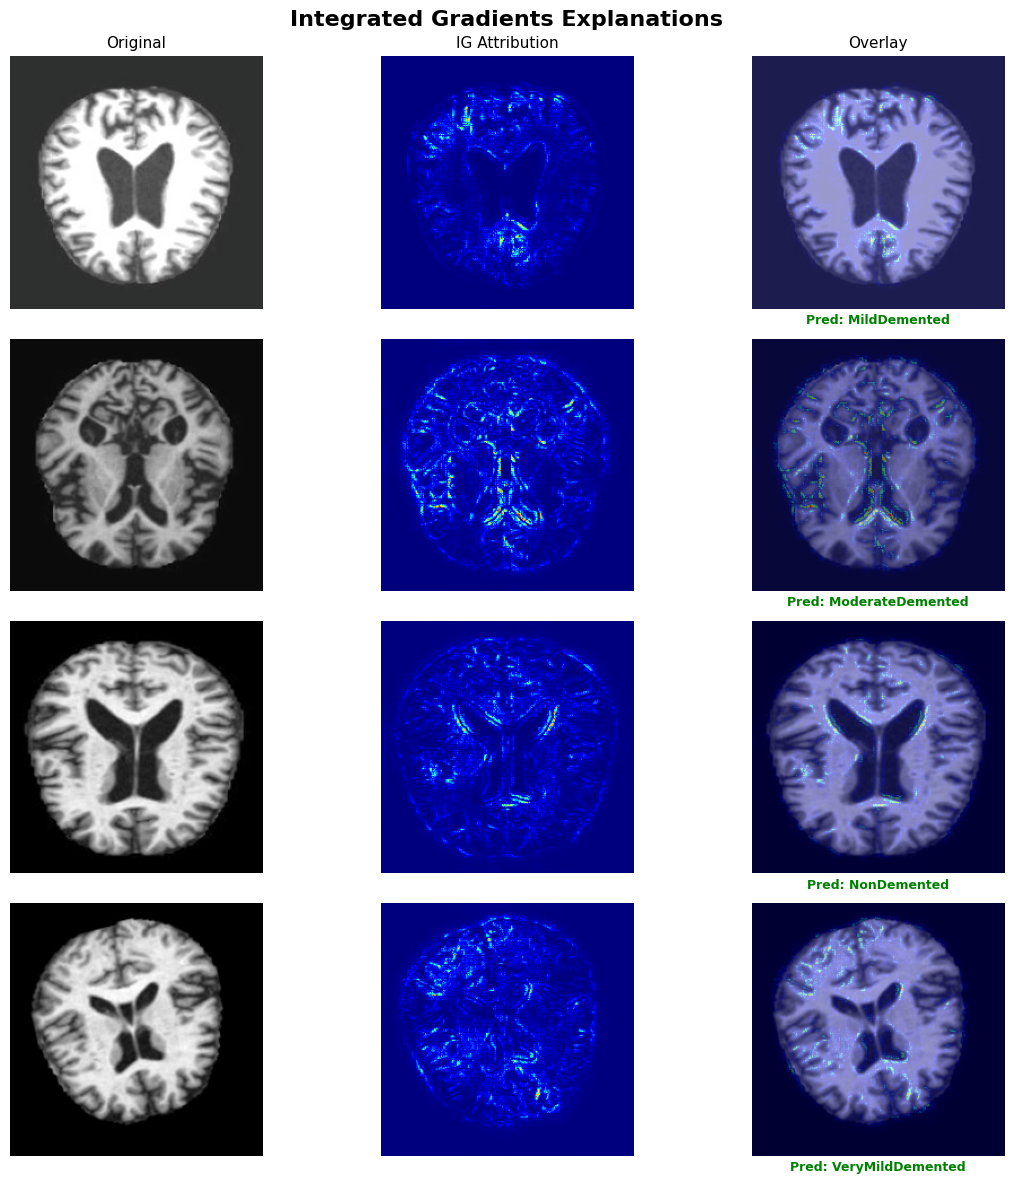

In [24]:
fig, axes = plt.subplots(NUM_CLASSES, 3, figsize=(12, NUM_CLASSES * 3))
fig.suptitle('Integrated Gradients Explanations', fontsize=16, fontweight='bold')

col_titles = ['Original', 'IG Attribution', 'Overlay']
for col, title in enumerate(col_titles):
    axes[0, col].set_title(title, fontsize=11)

for row, sample in enumerate(samples):
    img_tensor = sample['tensor']
    attributions, pred_class = ig_explainer.explain(img_tensor)

    img_np = denormalize_image(img_tensor).permute(1, 2, 0).numpy()

    ig_attr = attributions.squeeze().detach().numpy()
    ig_attr = np.transpose(ig_attr, (1, 2, 0))
    ig_attr = np.mean(np.abs(ig_attr), axis=2)
    ig_attr = (ig_attr - ig_attr.min()) / (ig_attr.max() - ig_attr.min() + 1e-8)

    color = 'green' if pred_class == sample['true'] else 'red'

    axes[row,0].imshow(img_np)
    axes[row,0].set_ylabel(CLASS_NAMES[sample['true']], fontsize=10, fontweight='bold')
    axes[row,0].axis('off')

    axes[row,1].imshow(ig_attr, cmap='jet')
    axes[row,1].axis('off')

    axes[row,2].imshow(apply_colormap(img_np, ig_attr))
    axes[row,2].axis('off')
    axes[row,2].text(0.5, -0.06, f"Pred: {CLASS_NAMES[pred_class]}",
                     transform=axes[row, 2].transAxes, ha='center', fontsize=9,
                     color=color, fontweight='bold')

    del attributions, ig_attr
    gc.collect()

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/XAI (mine)/ig_all_classes.png', dpi=150, bbox_inches='tight')
plt.show()